CSV files found:
1. OnePiece-Bounty - Sheet1.csv

Using CSV: /content/OnePiece-Bounty - Sheet1.csv

  STEP 1 | CONNECTING TO THE CSV
Connected to: /content/OnePiece-Bounty - Sheet1.csv
Shape: (165, 3)
Columns: ['S.no', 'Name', 'Bounty']


,S.no,Name,Bounty
0,1,Gol D. Roger,"฿5,564,800,000"
1,2,Edward Newgate,"฿5,046,000,000"
2,3,Kaidou,"฿4,611,100,000"
3,4,Charlotte Linlin,"฿4,388,000,000"
4,5,Shanks,"฿4,048,900,000"
5,6,Marshall D. Teach,"฿2,247,600,000"
6,7,Monkey D. Luffy,"฿1,500,000,000"
7,8,King,"฿1,390,000,000"


,S.no,Name,Bounty
160,999,Vasco Shot,Unknown
161,999,Vista,Unknown
162,999,Yasopp,Unknown
163,999,Yorki,Unknown
164,999,Zeff,Unknown


S.no       int64
Name      object
Bounty    object
dtype: object

Missing values per column:
 S.no      0
Name      0
Bounty    0
dtype: int64

Rows where Bounty is 'Unknown': 20
Rows with a non-Berry currency symbol: 1

  STEP 2 | CLEANING THE BOUNTY BOARD
status
Berry bounty             144
Unknown bounty            20
Yen bounty (excluded)      1
Name: count, dtype: int64
IQR lower fence on log10(bounty): 5.93 (~846,582 Berries)
Extreme low outliers removed (tiny legacy bounties that distort the fit):


,rank,Name,Bounty
142,144,Bepo,฿500
143,145,Tony Tony Chopper,฿100



Usable pirates for modelling: 142 | Mystery crew set aside: 20 | Outliers removed: 2
Duplicate names: 0

  STEP 3 | FEATURE ENGINEERING
Features: ['log_rank', 'name_len', 'word_count', 'has_initial', 'is_charlotte', 'is_placeholder', 'vowel_ratio']
Target  : log_bounty (log10 of bounty in Berries)

Heads-up: 'rank' (S.no) is produced by sorting bounties, so it leaks the target.
We keep it for a descriptive fit and run a rank-free ablation later to stay honest.


,rank,Name,bounty,log_bounty,tier,name_len,word_count,has_initial,is_charlotte,is_placeholder,vowel_ratio
0,1,Gol D. Roger,5.564800e+09,9.745450,1 Emperor-class,2.564949,3,1,0,0,0.333333
1,2,Edward Newgate,5.046000e+09,9.702947,1 Emperor-class,2.708050,2,0,0,0,0.384615
2,3,Kaidou,4.611100e+09,9.663805,1 Emperor-class,1.945910,1,0,0,0,0.666667
3,4,Charlotte Linlin,4.388000e+09,9.642267,1 Emperor-class,2.833213,2,0,1,0,0.333333
4,5,Shanks,4.048900e+09,9.607337,1 Emperor-class,1.945910,1,0,0,0,0.166667
5,6,Marshall D. Teach,2.247600e+09,9.351719,1 Emperor-class,2.890372,3,1,0,0,0.285714
6,7,Monkey D. Luffy,1.500000e+09,9.176091,1 Emperor-class,2.772589,3,1,0,0,0.250000
7,8,King,1.390000e+09,9.143015,1 Emperor-class,1.609438,1,0,0,0,0.250000



  STEP 4 | EDA


,count,mean,std,min,25%,50%,75%,max
bounty,142.0,3.950201e+08,9.031542e+08,3200000.000,3.275000e+07,9.450000e+07,3.375000e+08,5.564800e+09
log_bounty,142.0,8.024000e+00,7.170000e-01,6.505,7.515000e+00,7.975000e+00,8.528000e+00,9.745000e+00
log_rank,142.0,1.726000e+00,4.090000e-01,0.000,1.559000e+00,1.854000e+00,2.028000e+00,2.152000e+00
name_len,142.0,2.228000e+00,4.680000e-01,1.386,1.946000e+00,2.197000e+00,2.565000e+00,3.807000e+00
word_count,142.0,1.479000e+00,6.270000e-01,1.000,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00
has_initial,142.0,3.500000e-02,1.850000e-01,0.000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
is_charlotte,142.0,7.000000e-02,2.570000e-01,0.000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
is_placeholder,142.0,2.100000e-02,1.440000e-01,0.000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
vowel_ratio,142.0,3.940000e-01,1.110000e-01,0.167,3.330000e-01,3.860000e-01,5.000000e-01,7.500000e-01


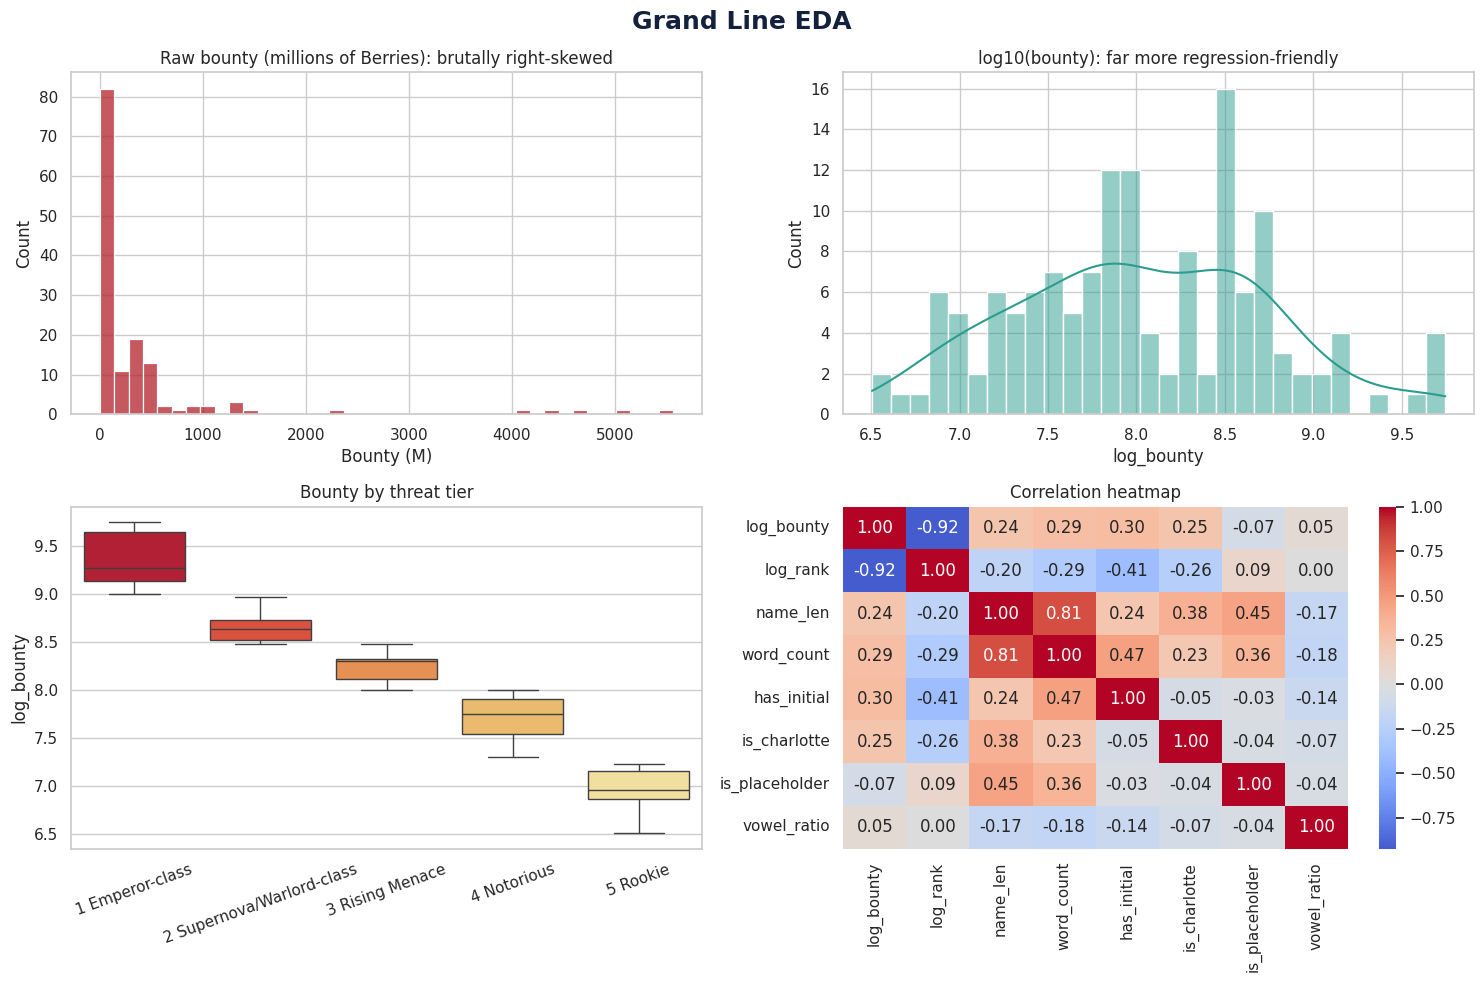

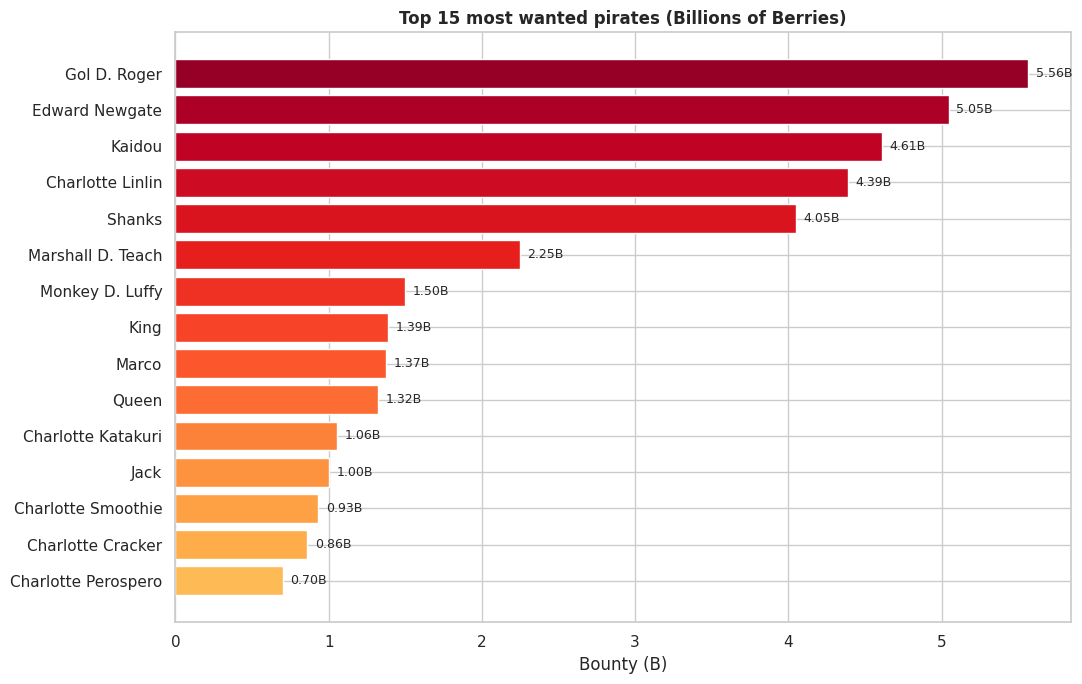


  STEP 5 | TRAIN / TEST SPLIT
Train: (113, 7) | Test: (29, 7)

  STEP 6 | BIAS-VARIANCE: HOW COMPLEX SHOULD THE MODEL BE?


,degree,n_features,OLS_train_R2,OLS_cv_R2,Ridge_train_R2,Ridge_cv_R2
0,1,7,0.866,0.835,0.862,0.833
1,2,35,0.962,0.812,0.952,0.887
2,3,119,0.994,0.042,0.989,0.776
3,4,329,0.997,-49.553,0.965,-1.366


Chosen polynomial degree (best Ridge CV R2): 2


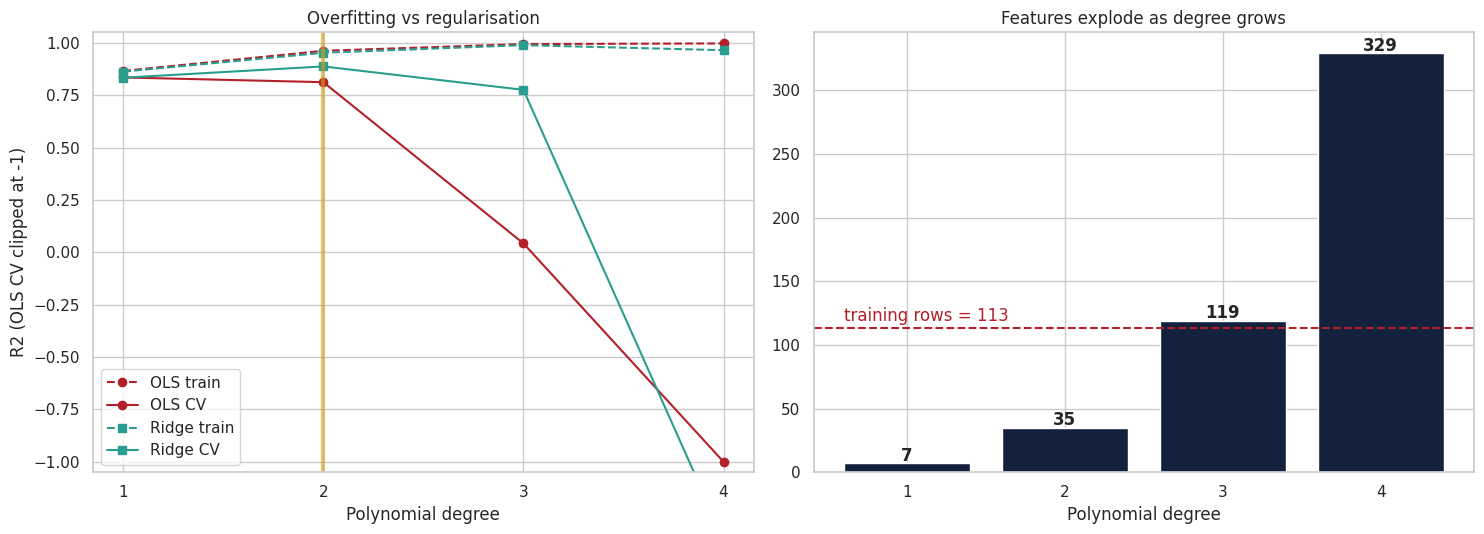


  STEP 7 | TRAINING OLS, RIDGE, LASSO, ELASTIC NET
OLS        -> no penalty
Ridge      -> alpha=3.6251
Lasso      -> alpha=0.02031
ElasticNet -> alpha=0.02219, l1_ratio=0.99

  STEP 8 | EVALUATION


,model,best_params,train_R2,test_R2,train_RMSE,test_RMSE,test_MAE,cv_RMSE,typical_miss_factor,nonzero_coefs,total_coefs,coef_L2_norm
0,OLS,no penalty,0.9618,0.8568,0.1415,0.2543,0.1670,0.3022,1.4691,35,35,1.0906
1,Ridge,alpha=3.6251,0.9523,0.9342,0.1581,0.1724,0.1492,0.2382,1.4099,35,35,0.8783
2,Lasso,alpha=0.02031,0.9401,0.9565,0.1772,0.1401,0.1220,0.2055,1.3245,7,35,0.8704
3,ElasticNet,"alpha=0.02219, l1_ratio=0.99",0.9384,0.9564,0.1798,0.1403,0.1216,0.1997,1.3230,7,35,0.8628



Best model by cross-validated RMSE (test set untouched): ElasticNet
typical_miss_factor = how many times too high/low a typical prediction is (1.0 = perfect).


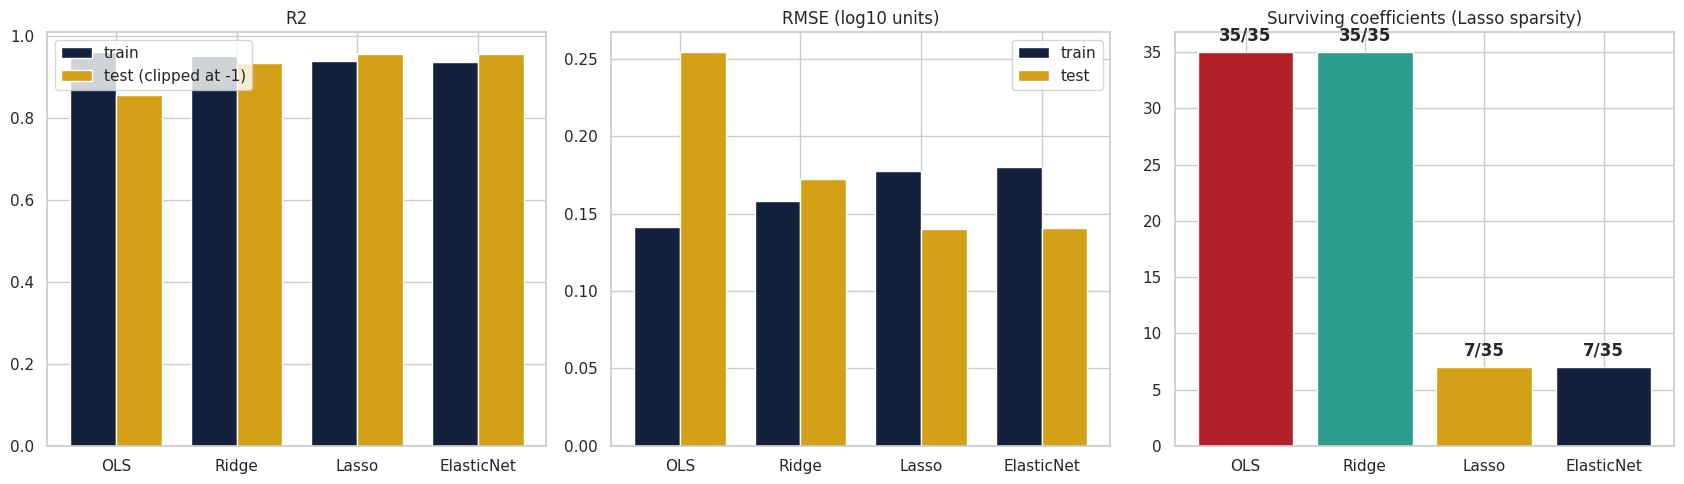


  STEP 9 | FINDING THE RIGHT PENALTY (ALPHA)


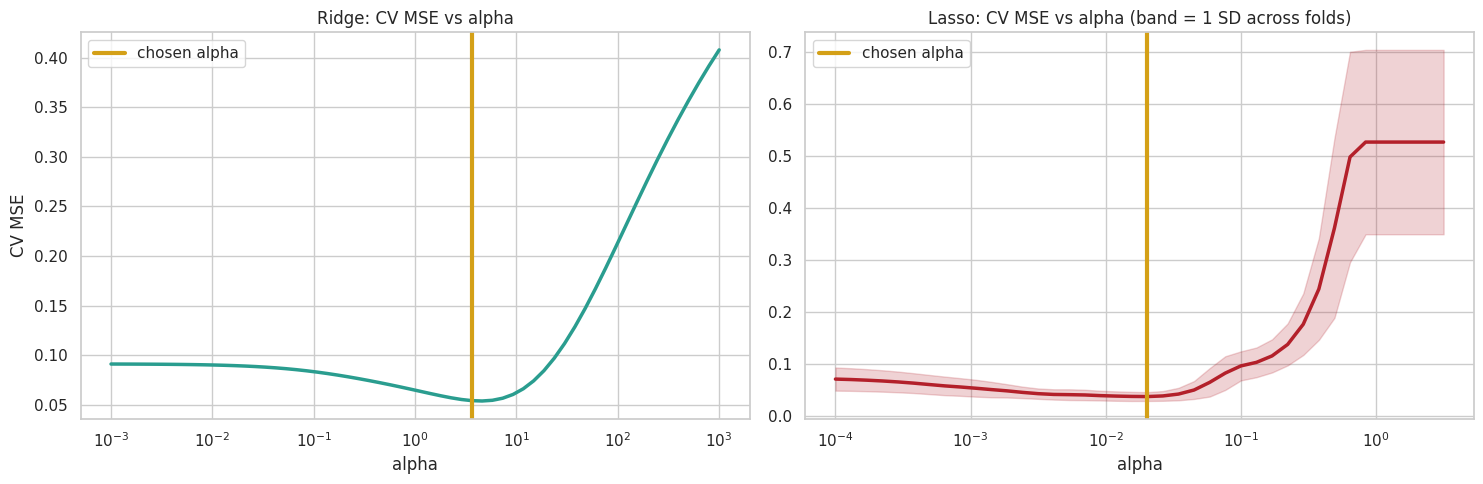

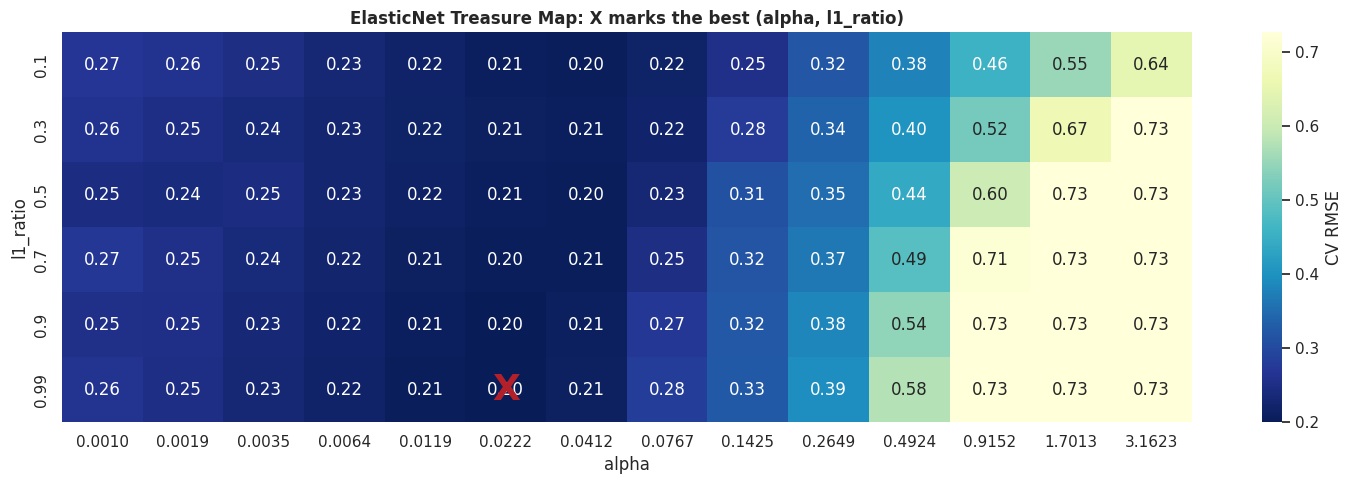

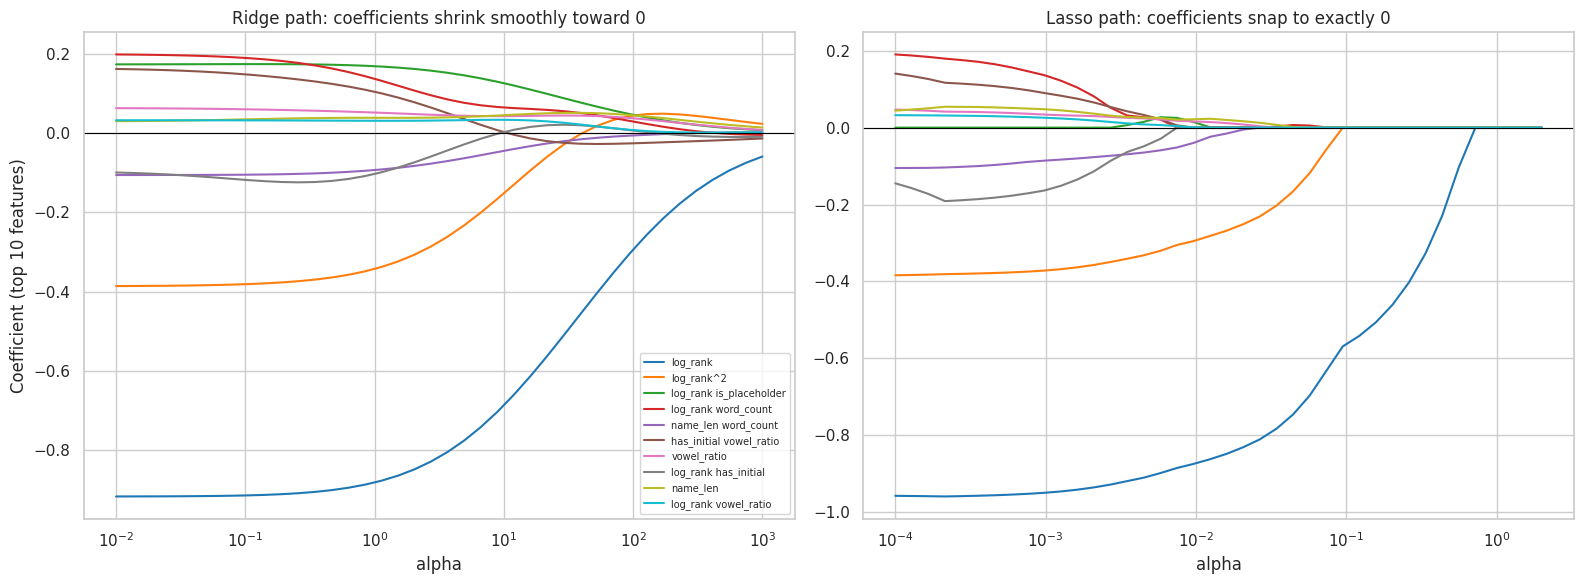


  STEP 10 | DIAGNOSTICS OF THE BEST MODEL


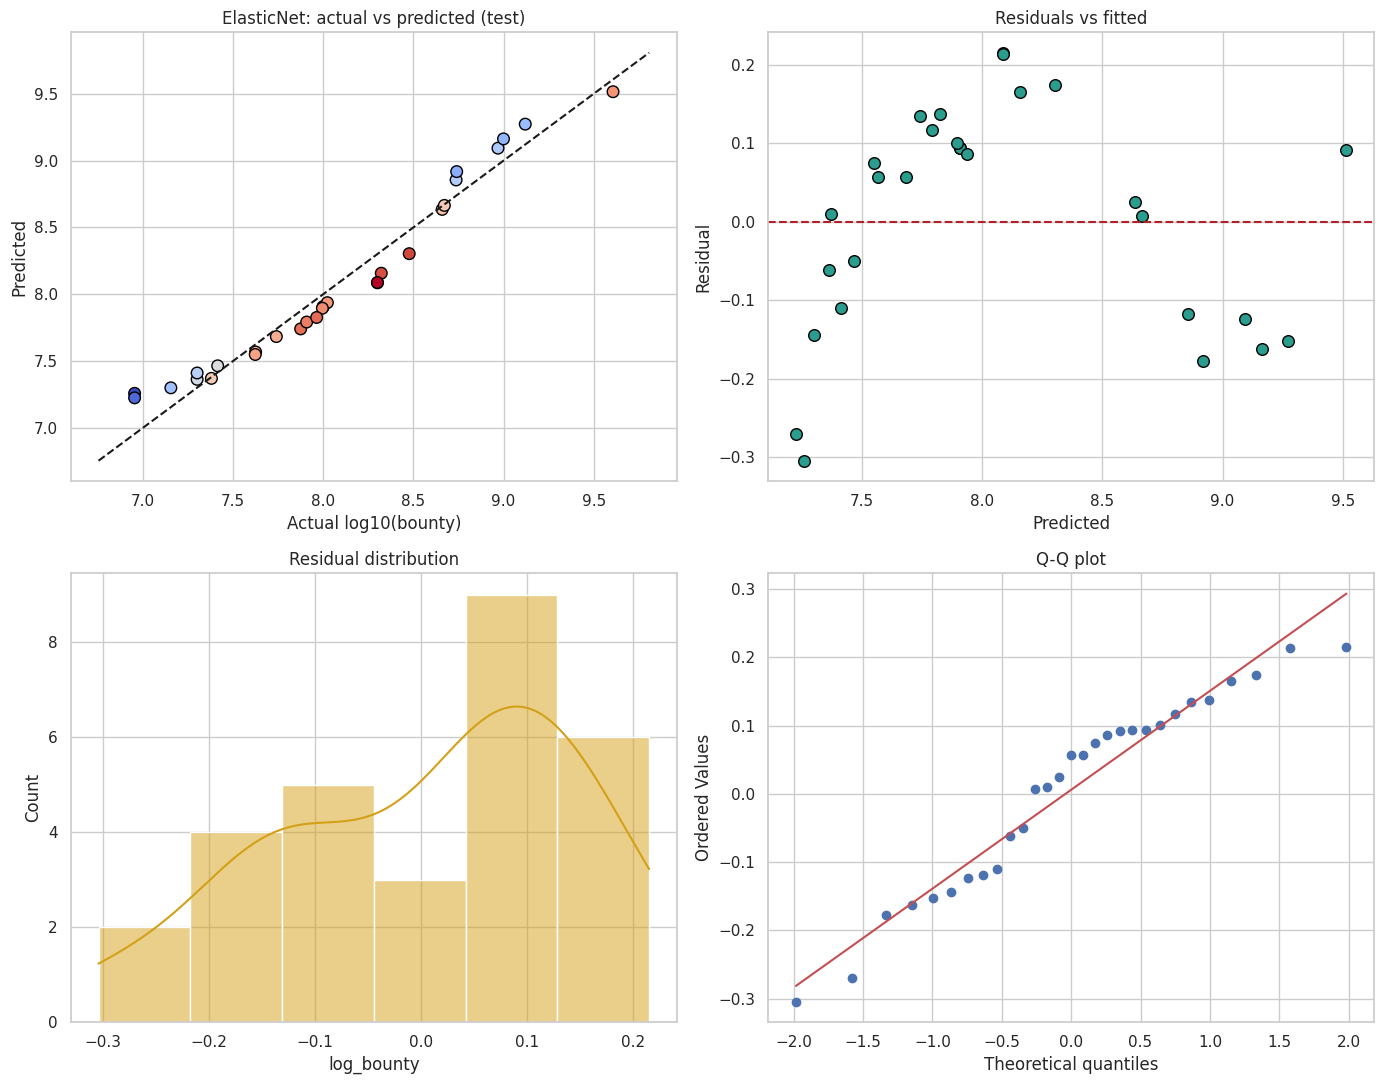

Shapiro-Wilk p-value on test residuals: 0.12

  STEP 11 | HONEST ABLATION: WHICH CLUES MATTER?


,feature_set,cv_R2_mean,cv_R2_std
0,Rank only,0.839,0.048
1,Name clues only (no rank),0.073,0.118
2,Rank + Name clues,0.848,0.034


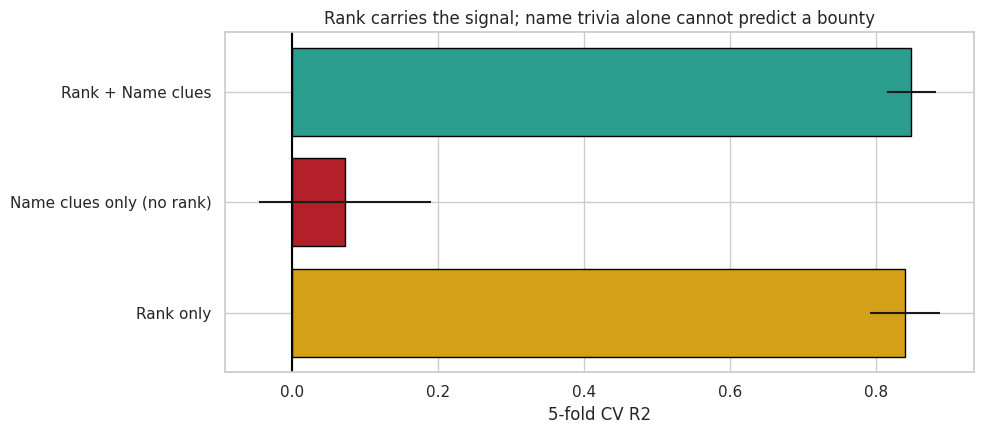


  STEP 12 | MARINE INTELLIGENCE: WHO BREAKS THE MODEL?


,rank,Name,bounty,log_bounty,tier,predicted_log,predicted_bounty,residual,verdict
0,142,Babe,3.200000e+06,6.505,5 Rookie,7.166,1.463911e+07,-0.660,UNDERPRICED vs model
1,141,Porchemy,3.400000e+06,6.531,5 Rookie,7.146,1.398559e+07,-0.614,UNDERPRICED vs model
2,140,Alvida,5.000000e+06,6.699,5 Rookie,7.171,1.484165e+07,-0.473,UNDERPRICED vs model
3,139,Chew,5.500000e+06,6.740,5 Rookie,7.200,1.586614e+07,-0.460,UNDERPRICED vs model
4,1,Gol D. Roger,5.564800e+09,9.745,1 Emperor-class,9.321,2.092731e+09,0.425,OVERPRICED vs model
5,137,Sham,7.000000e+06,6.845,5 Rookie,7.216,1.644015e+07,-0.371,UNDERPRICED vs model
6,137,Buchi,7.000000e+06,6.845,5 Rookie,7.206,1.605699e+07,-0.361,UNDERPRICED vs model
7,136,Mikita,7.500000e+06,6.875,5 Rookie,7.233,1.711076e+07,-0.358,UNDERPRICED vs model
8,133,Higuma,8.000000e+06,6.903,5 Rookie,7.257,1.805857e+07,-0.354,UNDERPRICED vs model
9,135,Curly Dadan,7.800000e+06,6.892,5 Rookie,7.240,1.738230e+07,-0.348,UNDERPRICED vs model


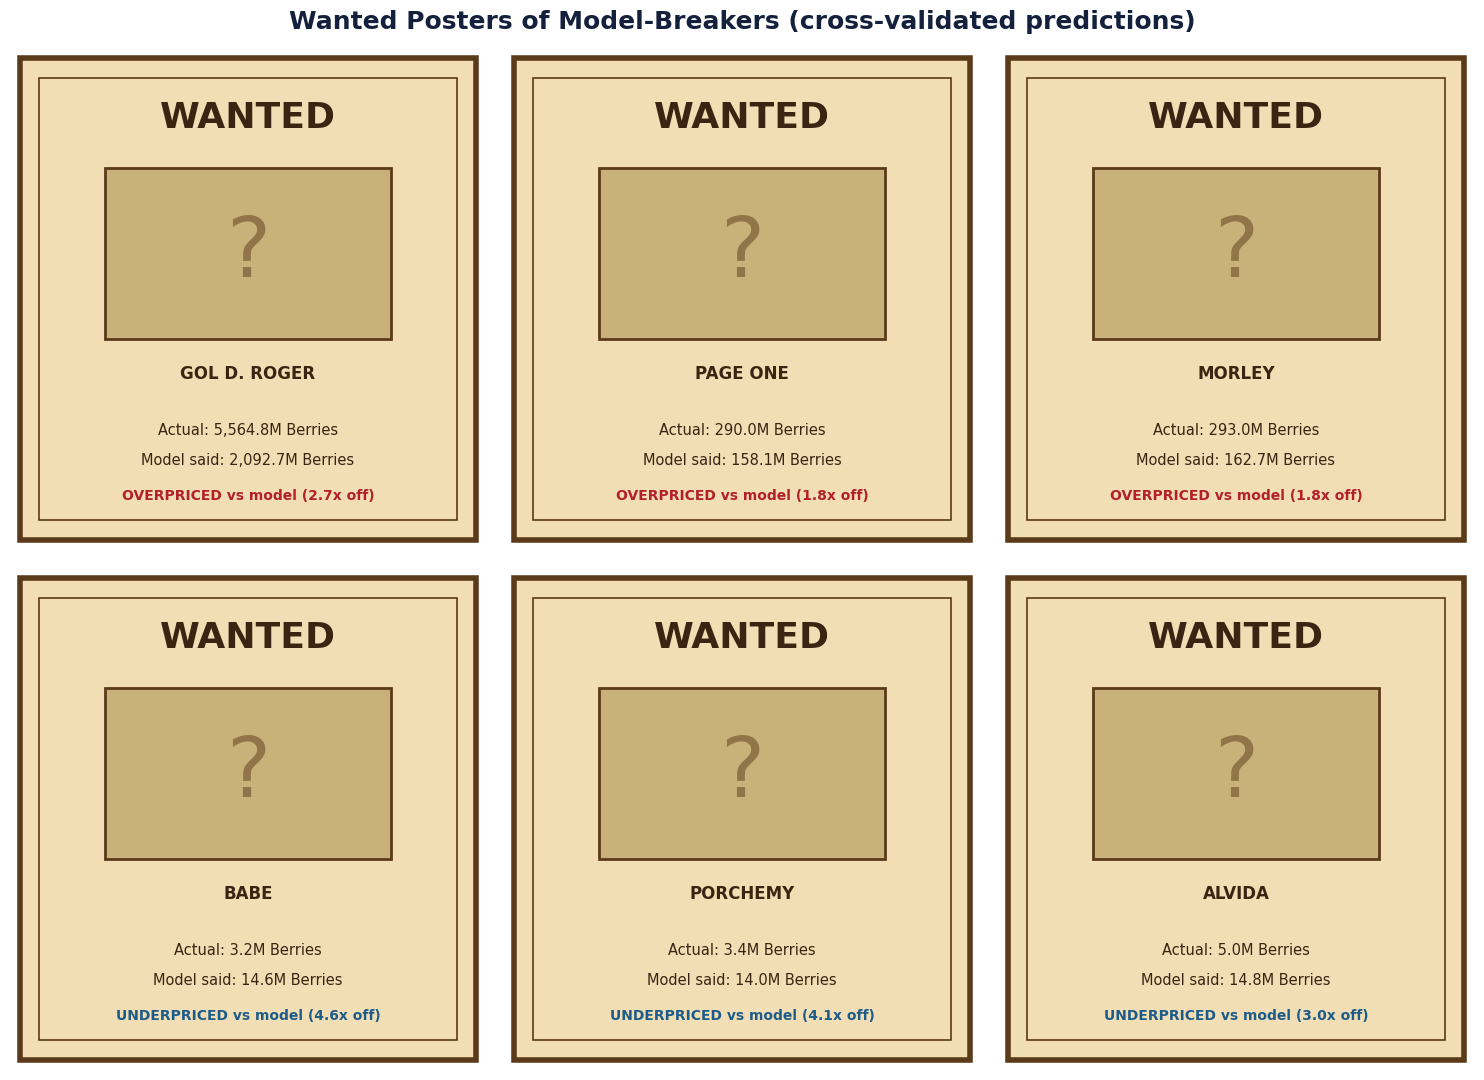


  STEP 13 | COEFFICIENT TABLE + EXPORTS


,feature,OLS,Ridge,Lasso,ElasticNet
0,log_rank,-0.9182,-0.8065,-0.8325,-0.8265
1,log_rank^2,-0.3866,-0.2622,-0.2523,-0.2463
2,log_rank is_placeholder,0.1744,0.1535,0.0000,0.0000
3,log_rank word_count,0.2008,0.0862,0.0000,0.0000
4,name_len word_count,-0.1053,-0.0702,-0.0057,-0.0021
5,has_initial vowel_ratio,0.1652,0.0515,0.0000,0.0000
6,vowel_ratio,0.0643,0.0458,0.0085,0.0072
7,log_rank has_initial,-0.0948,-0.0436,0.0000,0.0000
8,name_len,0.0299,0.0404,0.0167,0.0167
9,log_rank vowel_ratio,0.0333,0.0329,0.0000,0.0000


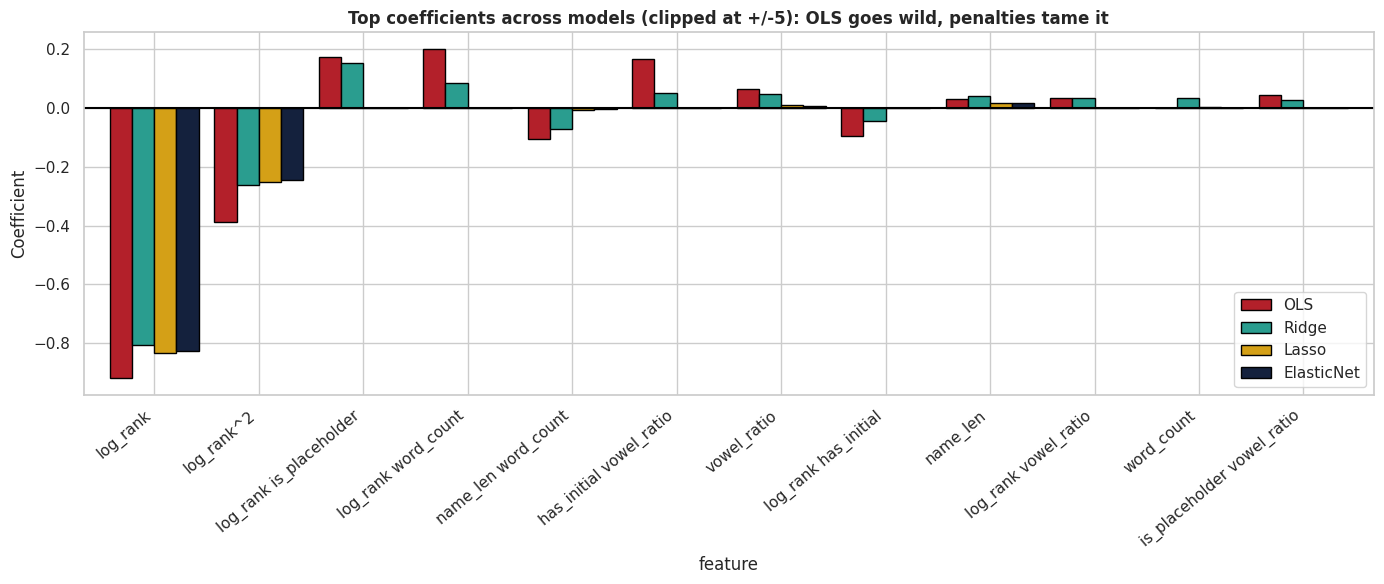

SKILL 4 | LINEAR REGRESSION AND REGULARISATION | ONE PIECE BOUNTY PROJECT

Rows used: 142 (Unknown bounties set aside: 20; low-bounty outliers removed: 2; yen bounty excluded: 1)
Target: log10(bounty in Berries)
Features: log_rank, name_len, word_count, has_initial, is_charlotte, is_placeholder, vowel_ratio
Polynomial degree chosen by Ridge CV: 2

Best model: ElasticNet (alpha=0.02219, l1_ratio=0.99)
Test R2: 0.956 | Test RMSE (log10): 0.140 | Typical miss factor: 1.32x

Model table:
     model  train_R2  test_R2  test_RMSE  cv_RMSE  nonzero_coefs
       OLS     0.962    0.857      0.254    0.302             35
     Ridge     0.952    0.934      0.172    0.238             35
     Lasso     0.940    0.957      0.140    0.206              7
ElasticNet     0.938    0.956      0.140    0.200              7

Ablation (5-fold CV R2):
              feature_set  cv_R2_mean  cv_R2_std
                Rank only       0.839      0.048
Name clues only (no rank)       0.073      0.118
        Rank 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import os, re, glob, shutil, textwrap, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

GOLD, CRIMSON, NAVY, TEAL, PARCH = "#d4a017", "#b3202a", "#14213d", "#2a9d8f", "#f1deb4"
SEED = 42
rng = np.random.RandomState(SEED)

CSV_FILES = glob.glob("/content/*.csv")

if not CSV_FILES:
    raise FileNotFoundError(
        "No CSV file found in /content. Upload your CSV using the Colab Files panel first."
    )

CSV_PATH = CSV_FILES[0]

print("CSV files found:")
for i, path in enumerate(CSV_FILES, 1):
    print(f"{i}. {os.path.basename(path)}")

print("\nUsing CSV:", CSV_PATH)

OUT_DIR = "/content/skill4_outputs"
FIG_DIR = os.path.join(OUT_DIR, "figures")

for d in (OUT_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

def shelf(fig_name):
    plt.savefig(
        os.path.join(FIG_DIR, fig_name),
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

def banner(text):
    print(
        "\n" +
        "=" * 78 +
        f"\n  {text}\n" +
        "=" * 78
    )

banner("STEP 1 | CONNECTING TO THE CSV")

raw = pd.read_csv(
    CSV_PATH,
    encoding="utf-8-sig"
)

raw.columns = raw.columns.str.strip()
raw["Name"] = raw["Name"].astype(str).str.strip()

print("Connected to:", CSV_PATH)
print("Shape:", raw.shape)
print("Columns:", list(raw.columns))

display(raw.head(8))
display(raw.tail(5))

print(raw.dtypes)

print("\nMissing values per column:\n", raw.isna().sum())

print(
    "\nRows where Bounty is 'Unknown':",
    (
        raw["Bounty"]
        .str.strip()
        .str.lower()
        == "unknown"
    ).sum()
)

print(
    "Rows with a non-Berry currency symbol:",
    (
        ~raw["Bounty"].str.startswith(("฿", "Unknown"))
    ).sum()
)

banner("STEP 2 | CLEANING THE BOUNTY BOARD")

def parse_berries(value):
    s = str(value).strip()

    if s.lower() == "unknown" or s.startswith("¥"):
        return np.nan

    digits = re.sub(r"[^0-9]", "", s)

    return float(digits) if digits else np.nan

df = raw.rename(
    columns={"S.no": "rank"}
).copy()

df["bounty"] = df["Bounty"].apply(parse_berries)

df["status"] = np.where(
    df["Bounty"].str.lower().str.strip() == "unknown",
    "Unknown bounty",
    np.where(
        df["Bounty"].str.startswith("¥"),
        "Yen bounty (excluded)",
        "Berry bounty"
    )
)

print(df["status"].value_counts())

mystery = df[
    df["status"] == "Unknown bounty"
].copy()

data = df[
    df["status"] == "Berry bounty"
].copy().reset_index(drop=True)

data["log_bounty"] = np.log10(
    data["bounty"]
)

q1, q3 = data[
    "log_bounty"
].quantile([0.25, 0.75])

lower_fence = q1 - 1.5 * (
    q3 - q1
)

outliers = data[
    data["log_bounty"] < lower_fence
].copy()

data = data[
    data["log_bounty"] >= lower_fence
].reset_index(drop=True)

print(
    f"IQR lower fence on log10(bounty): "
    f"{lower_fence:.2f} "
    f"(~{10 ** lower_fence:,.0f} Berries)"
)

print(
    "Extreme low outliers removed "
    "(tiny legacy bounties that distort the fit):"
)

display(
    outliers[
        ["rank", "Name", "Bounty"]
    ]
)

print(
    f"\nUsable pirates for modelling: {len(data)} | "
    f"Mystery crew set aside: {len(mystery)} | "
    f"Outliers removed: {len(outliers)}"
)

print(
    "Duplicate names:",
    data["Name"].duplicated().sum()
)

def tier(b):
    if b >= 1e9:
        return "1 Emperor-class"
    if b >= 3e8:
        return "2 Supernova/Warlord-class"
    if b >= 1e8:
        return "3 Rising Menace"
    if b >= 2e7:
        return "4 Notorious"
    return "5 Rookie"

data["tier"] = data["bounty"].apply(tier)

banner("STEP 3 | FEATURE ENGINEERING")

data["log_rank"] = np.log10(
    data["rank"]
)

data["name_len"] = np.log1p(
    data["Name"].str.len()
)

data["word_count"] = (
    data["Name"]
    .str.split()
    .str.len()
    .clip(upper=3)
)

data["has_initial"] = (
    data["Name"]
    .str.contains(
        r"\b[A-Z]\.",
        regex=True
    )
    .astype(int)
)

data["is_charlotte"] = (
    data["Name"]
    .str.startswith("Charlotte")
    .astype(int)
)

data["is_placeholder"] = (
    data["Name"]
    .str.startswith("(")
    .astype(int)
)

data["vowel_ratio"] = data["Name"].apply(
    lambda s:
    sum(c in "aeiouAEIOU" for c in s)
    /
    max(
        1,
        sum(c.isalpha() for c in s)
    )
)

RANK_FEATS = [
    "log_rank"
]

NAME_FEATS = [
    "name_len",
    "word_count",
    "has_initial",
    "is_charlotte",
    "is_placeholder",
    "vowel_ratio"
]

FEATURES = RANK_FEATS + NAME_FEATS

TARGET = "log_bounty"

print("Features:", FEATURES)
print(
    "Target  :",
    TARGET,
    "(log10 of bounty in Berries)"
)

print(
    "\nHeads-up: 'rank' (S.no) is produced by sorting bounties, so it leaks the target."
)

print(
    "We keep it for a descriptive fit and run a rank-free ablation later to stay honest."
)

display(
    data[
        [
            "rank",
            "Name",
            "bounty",
            "log_bounty",
            "tier"
        ] + NAME_FEATS
    ].head(8)
)

banner("STEP 4 | EDA")

display(
    data[
        ["bounty", "log_bounty"] + FEATURES
    ].describe().T.round(3)
)

fig, ax = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

sns.histplot(
    data["bounty"] / 1e6,
    bins=40,
    color=CRIMSON,
    ax=ax[0, 0]
)

ax[0, 0].set_title(
    "Raw bounty (millions of Berries): brutally right-skewed"
)

ax[0, 0].set_xlabel(
    "Bounty (M)"
)

sns.histplot(
    data["log_bounty"],
    bins=30,
    kde=True,
    color=TEAL,
    ax=ax[0, 1]
)

ax[0, 1].set_title(
    "log10(bounty): far more regression-friendly"
)

tier_order = sorted(
    data["tier"].unique()
)

sns.boxplot(
    data=data,
    x="tier",
    y="log_bounty",
    order=tier_order,
    palette="YlOrRd_r",
    ax=ax[1, 0]
)

ax[1, 0].set_title(
    "Bounty by threat tier"
)

ax[1, 0].tick_params(
    axis="x",
    rotation=20
)

ax[1, 0].set_xlabel("")

corr = data[
    [TARGET] + FEATURES
].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax[1, 1]
)

ax[1, 1].set_title(
    "Correlation heatmap"
)

plt.suptitle(
    "Grand Line EDA",
    fontsize=18,
    fontweight="bold",
    color=NAVY
)

plt.tight_layout()

shelf(
    "01_eda_overview.png"
)

top15 = data.nlargest(
    15,
    "bounty"
).iloc[::-1]

fig, ax = plt.subplots(
    figsize=(11, 7)
)

bars = ax.barh(
    top15["Name"],
    top15["bounty"] / 1e9,
    color=plt.cm.YlOrRd(
        np.linspace(
            0.35,
            0.95,
            15
        )
    )
)

for b, v in zip(
    bars,
    top15["bounty"] / 1e9
):
    ax.text(
        v + 0.05,
        b.get_y() + b.get_height() / 2,
        f"{v:.2f}B",
        va="center",
        fontsize=9
    )

ax.set_title(
    "Top 15 most wanted pirates (Billions of Berries)",
    fontweight="bold"
)

ax.set_xlabel(
    "Bounty (B)"
)

plt.tight_layout()

shelf(
    "02_top15_bounties.png"
)

fig = px.scatter(
    data,
    x="log_rank",
    y="log_bounty",
    color="tier",
    hover_name="Name",
    hover_data={
        "bounty": ":,.0f",
        "rank": True,
        "log_rank": False,
        "log_bounty": ":.2f"
    },
    category_orders={
        "tier": tier_order
    },
    color_discrete_sequence=px.colors.sequential.YlOrRd_r,
    title="Grand Line Map: every pirate by rank and bounty (hover for names)"
)

fig.update_traces(
    marker=dict(
        size=10,
        line=dict(
            width=1,
            color="black"
        )
    )
)

fig.update_layout(
    template="plotly_dark",
    xaxis_title="log10(rank)",
    yaxis_title="log10(bounty)"
)

fig.write_html(
    os.path.join(
        OUT_DIR,
        "grand_line_map.html"
    )
)

fig.show()

banner("STEP 5 | TRAIN / TEST SPLIT")

X = data[FEATURES]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED
)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

print(
    "Train:",
    X_train.shape,
    "| Test:",
    X_test.shape
)

def make_pipe(model, degree):
    return Pipeline([
        (
            "pre",
            StandardScaler()
        ),
        (
            "poly",
            PolynomialFeatures(
                degree=degree,
                include_bias=False
            )
        ),
        (
            "scale",
            StandardScaler()
        ),
        (
            "model",
            model
        )
    ])

RIDGE_ALPHAS = np.logspace(
    -3,
    3,
    60
)

LASSO_ALPHAS = np.logspace(
    -4,
    0.5,
    40
)

banner(
    "STEP 6 | BIAS-VARIANCE: HOW COMPLEX SHOULD THE MODEL BE?"
)

degree_rows = []

for d in [1, 2, 3, 4]:

    ols_p = make_pipe(
        LinearRegression(),
        d
    )

    rdg_p = make_pipe(
        RidgeCV(
            alphas=RIDGE_ALPHAS
        ),
        d
    )

    n_feat = (
        ols_p
        .fit(
            X_train,
            y_train
        )
        .named_steps["poly"]
        .n_output_features_
    )

    degree_rows.append({
        "degree": d,
        "n_features": n_feat,
        "OLS_train_R2": ols_p.score(
            X_train,
            y_train
        ),
        "OLS_cv_R2": cross_val_score(
            make_pipe(
                LinearRegression(),
                d
            ),
            X_train,
            y_train,
            cv=kf,
            scoring="r2"
        ).mean(),
        "Ridge_train_R2": rdg_p.fit(
            X_train,
            y_train
        ).score(
            X_train,
            y_train
        ),
        "Ridge_cv_R2": cross_val_score(
            make_pipe(
                RidgeCV(
                    alphas=RIDGE_ALPHAS
                ),
                d
            ),
            X_train,
            y_train,
            cv=kf,
            scoring="r2"
        ).mean()
    })

degree_df = pd.DataFrame(
    degree_rows
)

display(
    degree_df.round(3)
)

DEG = int(
    degree_df.loc[
        degree_df["Ridge_cv_R2"].idxmax(),
        "degree"
    ]
)

print(
    f"Chosen polynomial degree (best Ridge CV R2): {DEG}"
)

fig, ax = plt.subplots(
    1,
    2,
    figsize=(15, 5.5)
)

ax[0].plot(
    degree_df["degree"],
    degree_df["OLS_train_R2"],
    "o--",
    color=CRIMSON,
    label="OLS train"
)

ax[0].plot(
    degree_df["degree"],
    degree_df["OLS_cv_R2"].clip(lower=-1),
    "o-",
    color=CRIMSON,
    label="OLS CV"
)

ax[0].plot(
    degree_df["degree"],
    degree_df["Ridge_train_R2"],
    "s--",
    color=TEAL,
    label="Ridge train"
)

ax[0].plot(
    degree_df["degree"],
    degree_df["Ridge_cv_R2"],
    "s-",
    color=TEAL,
    label="Ridge CV"
)

ax[0].axvline(
    DEG,
    color=GOLD,
    lw=3,
    alpha=0.6
)

ax[0].set_ylim(
    -1.05,
    1.05
)

ax[0].set_xticks(
    degree_df["degree"]
)

ax[0].set_xlabel(
    "Polynomial degree"
)

ax[0].set_ylabel(
    "R2 (OLS CV clipped at -1)"
)

ax[0].set_title(
    "Overfitting vs regularisation"
)

ax[0].legend()

ax[1].bar(
    degree_df["degree"].astype(str),
    degree_df["n_features"],
    color=NAVY
)

for i, v in enumerate(
    degree_df["n_features"]
):
    ax[1].text(
        i,
        v + 2,
        str(v),
        ha="center",
        fontweight="bold"
    )

ax[1].axhline(
    len(X_train),
    color=CRIMSON,
    ls="--"
)

ax[1].text(
    -0.4,
    len(X_train) + 6,
    f"training rows = {len(X_train)}",
    color=CRIMSON
)

ax[1].set_title(
    "Features explode as degree grows"
)

ax[1].set_xlabel(
    "Polynomial degree"
)

plt.tight_layout()

shelf(
    "03_bias_variance_degree.png"
)

banner(
    "STEP 7 | TRAINING OLS, RIDGE, LASSO, ELASTIC NET"
)

ols = make_pipe(
    LinearRegression(),
    DEG
).fit(
    X_train,
    y_train
)

ridge = make_pipe(
    RidgeCV(
        alphas=RIDGE_ALPHAS,
        cv=kf
    ),
    DEG
).fit(
    X_train,
    y_train
)

lasso = make_pipe(
    LassoCV(
        alphas=LASSO_ALPHAS,
        cv=kf,
        max_iter=200000,
        random_state=SEED
    ),
    DEG
).fit(
    X_train,
    y_train
)

enet_grid = GridSearchCV(
    make_pipe(
        ElasticNet(
            max_iter=200000,
            random_state=SEED
        ),
        DEG
    ),
    {
        "model__alpha": np.logspace(
            -3,
            0.5,
            14
        ),
        "model__l1_ratio": [
            0.1,
            0.3,
            0.5,
            0.7,
            0.9,
            0.99
        ]
    },
    cv=kf,
    scoring="neg_mean_squared_error",
    n_jobs=-1
).fit(
    X_train,
    y_train
)

enet = enet_grid.best_estimator_

models = {
    "OLS": ols,
    "Ridge": ridge,
    "Lasso": lasso,
    "ElasticNet": enet
}

best_params = {
    "OLS": "no penalty",
    "Ridge": (
        f"alpha={ridge.named_steps['model'].alpha_:.4f}"
    ),
    "Lasso": (
        f"alpha={lasso.named_steps['model'].alpha_:.5f}"
    ),
    "ElasticNet": (
        f"alpha={enet_grid.best_params_['model__alpha']:.5f}, "
        f"l1_ratio={enet_grid.best_params_['model__l1_ratio']}"
    )
}

for k, v in best_params.items():
    print(
        f"{k:<11}-> {v}"
    )

banner("STEP 8 | EVALUATION")

rows = []

for name, m in models.items():

    ptr = m.predict(X_train)
    pte = m.predict(X_test)

    coefs = m.named_steps[
        "model"
    ].coef_

    cv_mse = -cross_val_score(
        clone(m),
        X_train,
        y_train,
        cv=kf,
        scoring="neg_mean_squared_error"
    )

    rows.append({
        "model": name,
        "best_params": best_params[name],
        "train_R2": r2_score(
            y_train,
            ptr
        ),
        "test_R2": r2_score(
            y_test,
            pte
        ),
        "train_RMSE": np.sqrt(
            mean_squared_error(
                y_train,
                ptr
            )
        ),
        "test_RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                pte
            )
        ),
        "test_MAE": mean_absolute_error(
            y_test,
            pte
        ),
        "cv_RMSE": np.sqrt(
            cv_mse.mean()
        ),
        "typical_miss_factor": (
            10 **
            mean_absolute_error(
                y_test,
                pte
            )
        ),
        "nonzero_coefs": int(
            (
                np.abs(coefs) > 1e-8
            ).sum()
        ),
        "total_coefs": len(coefs),
        "coef_L2_norm": float(
            np.linalg.norm(coefs)
        )
    })

metrics = pd.DataFrame(
    rows
)

display(
    metrics.round(4)
)

best_name = metrics.loc[
    metrics["cv_RMSE"].idxmin(),
    "model"
]

best_model = models[
    best_name
]

print(
    f"\nBest model by cross-validated RMSE (test set untouched): {best_name}"
)

print(
    "typical_miss_factor = how many times too high/low a typical prediction is (1.0 = perfect)."
)

fig, ax = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)

w = 0.38

xs = np.arange(
    len(metrics)
)

ax[0].bar(
    xs - w / 2,
    metrics["train_R2"],
    w,
    label="train",
    color=NAVY
)

ax[0].bar(
    xs + w / 2,
    metrics["test_R2"].clip(
        lower=-1
    ),
    w,
    label="test (clipped at -1)",
    color=GOLD
)

ax[0].set_xticks(
    xs
)

ax[0].set_xticklabels(
    metrics["model"]
)

ax[0].set_title(
    "R2"
)

ax[0].legend()

ax[1].bar(
    xs - w / 2,
    metrics["train_RMSE"],
    w,
    color=NAVY,
    label="train"
)

ax[1].bar(
    xs + w / 2,
    metrics["test_RMSE"],
    w,
    color=GOLD,
    label="test"
)

ax[1].set_xticks(
    xs
)

ax[1].set_xticklabels(
    metrics["model"]
)

ax[1].set_title(
    "RMSE (log10 units)"
)

ax[1].legend()

ax[2].bar(
    metrics["model"],
    metrics["nonzero_coefs"],
    color=[
        CRIMSON,
        TEAL,
        GOLD,
        NAVY
    ]
)

for i, (nz, tot) in enumerate(
    zip(
        metrics["nonzero_coefs"],
        metrics["total_coefs"]
    )
):
    ax[2].text(
        i,
        nz + 1,
        f"{nz}/{tot}",
        ha="center",
        fontweight="bold"
    )

ax[2].set_title(
    "Surviving coefficients (Lasso sparsity)"
)

plt.tight_layout()

shelf(
    "04_model_comparison.png"
)

banner(
    "STEP 9 | FINDING THE RIGHT PENALTY (ALPHA)"
)

ridge_cv_curve = [
    -cross_val_score(
        make_pipe(
            Ridge(alpha=a),
            DEG
        ),
        X_train,
        y_train,
        cv=kf,
        scoring="neg_mean_squared_error"
    ).mean()
    for a in RIDGE_ALPHAS
]

lasso_model = lasso.named_steps[
    "model"
]

fig, ax = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

ax[0].semilogx(
    RIDGE_ALPHAS,
    ridge_cv_curve,
    color=TEAL,
    lw=2.5
)

ax[0].axvline(
    ridge.named_steps["model"].alpha_,
    color=GOLD,
    lw=3,
    label="chosen alpha"
)

ax[0].set_title(
    "Ridge: CV MSE vs alpha"
)

ax[0].set_xlabel(
    "alpha"
)

ax[0].set_ylabel(
    "CV MSE"
)

ax[0].legend()

mse_mean = (
    lasso_model
    .mse_path_
    .mean(axis=1)
)

mse_sd = (
    lasso_model
    .mse_path_
    .std(axis=1)
)

ax[1].semilogx(
    lasso_model.alphas_,
    mse_mean,
    color=CRIMSON,
    lw=2.5
)

ax[1].fill_between(
    lasso_model.alphas_,
    mse_mean - mse_sd,
    mse_mean + mse_sd,
    color=CRIMSON,
    alpha=0.2
)

ax[1].axvline(
    lasso_model.alpha_,
    color=GOLD,
    lw=3,
    label="chosen alpha"
)

ax[1].set_title(
    "Lasso: CV MSE vs alpha (band = 1 SD across folds)"
)

ax[1].set_xlabel(
    "alpha"
)

ax[1].legend()

plt.tight_layout()

shelf(
    "05_alpha_curves.png"
)

grid_df = pd.DataFrame(
    enet_grid.cv_results_
)

pivot = grid_df.pivot_table(
    index="param_model__l1_ratio",
    columns="param_model__alpha",
    values="mean_test_score"
)

pivot = np.sqrt(
    -pivot
)

pivot.columns = [
    f"{c:.4f}"
    for c in pivot.columns.astype(float)
]

fig, ax = plt.subplots(
    figsize=(15, 5)
)

sns.heatmap(
    pivot,
    cmap="YlGnBu_r",
    annot=True,
    fmt=".2f",
    cbar_kws={
        "label": "CV RMSE"
    },
    ax=ax
)

bi = list(
    pivot.index
).index(
    enet_grid.best_params_[
        "model__l1_ratio"
    ]
)

bj = int(
    np.argmin(
        np.abs(
            np.array(
                pivot.columns,
                dtype=float
            )
            -
            enet_grid.best_params_[
                "model__alpha"
            ]
        )
    )
)

ax.text(
    bj + 0.5,
    bi + 0.5,
    "X",
    color=CRIMSON,
    ha="center",
    va="center",
    fontsize=26,
    fontweight="bold"
)

ax.set_title(
    "ElasticNet Treasure Map: X marks the best (alpha, l1_ratio)",
    fontweight="bold"
)

ax.set_xlabel(
    "alpha"
)

ax.set_ylabel(
    "l1_ratio"
)

plt.tight_layout()

shelf(
    "06_elasticnet_treasure_map.png"
)

pre = Pipeline(
    ols.steps[:3]
).fit(
    X_train
)

Xtr_t = pre.transform(
    X_train
)

feat_names = (
    pre
    .named_steps["poly"]
    .get_feature_names_out(
        FEATURES
    )
)

TOPK = min(
    10,
    len(feat_names)
)

top_idx = np.argsort(
    -np.abs(
        ridge.named_steps[
            "model"
        ].coef_
    )
)[:TOPK]

path_alphas = np.logspace(
    -2,
    3,
    40
)

ridge_path = np.array([
    Ridge(
        alpha=a
    )
    .fit(
        Xtr_t,
        y_train
    )
    .coef_[top_idx]
    for a in path_alphas
])

lasso_path_alphas = np.logspace(
    -4,
    0.3,
    40
)

lasso_path = np.array([
    Lasso(
        alpha=a,
        max_iter=200000
    )
    .fit(
        Xtr_t,
        y_train
    )
    .coef_[top_idx]
    for a in lasso_path_alphas
])

fig, ax = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

cmap = plt.cm.tab10(
    np.arange(10)
)

for j in range(TOPK):

    ax[0].semilogx(
        path_alphas,
        ridge_path[:, j],
        color=cmap[j],
        label=feat_names[
            top_idx[j]
        ]
    )

    ax[1].semilogx(
        lasso_path_alphas,
        lasso_path[:, j],
        color=cmap[j]
    )

ax[0].set_title(
    "Ridge path: coefficients shrink smoothly toward 0"
)

ax[1].set_title(
    "Lasso path: coefficients snap to exactly 0"
)

for a in ax:
    a.axhline(
        0,
        color="black",
        lw=0.8
    )

    a.set_xlabel(
        "alpha"
    )

ax[0].set_ylabel(
    "Coefficient (top 10 features)"
)

ax[0].legend(
    fontsize=7,
    loc="best"
)

plt.tight_layout()

shelf(
    "07_regularisation_paths.png"
)

path_long = pd.DataFrame({
    "alpha": np.repeat(
        [
            f"{a:.3f}"
            for a in path_alphas[::3]
        ],
        TOPK
    ),
    "feature": np.tile(
        [
            feat_names[i]
            for i in top_idx
        ],
        len(
            path_alphas[::3]
        )
    ),
    "coefficient": ridge_path[
        ::3
    ].ravel()
})

lim = (
    float(
        np.nanpercentile(
            np.abs(
                path_long[
                    "coefficient"
                ]
            ),
            98
        )
    ) * 1.2
)

race = px.bar(
    path_long,
    x="coefficient",
    y="feature",
    animation_frame="alpha",
    orientation="h",
    range_x=[
        -lim,
        lim
    ],
    color="coefficient",
    color_continuous_scale="RdYlBu_r",
    title="Shrinkage Race: press play and watch Ridge squeeze the coefficients"
)

race.update_layout(
    template="plotly_dark",
    yaxis={
        "categoryorder":
        "total ascending"
    }
)

race.write_html(
    os.path.join(
        OUT_DIR,
        "ridge_shrinkage_race.html"
    )
)

race.show()

banner(
    "STEP 10 | DIAGNOSTICS OF THE BEST MODEL"
)

pred_test = best_model.predict(
    X_test
)

resid_test = (
    y_test -
    pred_test
)

fig, ax = plt.subplots(
    2,
    2,
    figsize=(14, 11)
)

ax[0, 0].scatter(
    y_test,
    pred_test,
    c=resid_test,
    cmap="coolwarm",
    edgecolor="black",
    s=70
)

lims = [
    min(
        y_test.min(),
        pred_test.min()
    ) - 0.2,
    max(
        y_test.max(),
        pred_test.max()
    ) + 0.2
]

ax[0, 0].plot(
    lims,
    lims,
    "k--"
)

ax[0, 0].set_title(
    f"{best_name}: actual vs predicted (test)"
)

ax[0, 0].set_xlabel(
    "Actual log10(bounty)"
)

ax[0, 0].set_ylabel(
    "Predicted"
)

ax[0, 1].scatter(
    pred_test,
    resid_test,
    color=TEAL,
    edgecolor="black",
    s=70
)

ax[0, 1].axhline(
    0,
    color=CRIMSON,
    ls="--"
)

ax[0, 1].set_title(
    "Residuals vs fitted"
)

ax[0, 1].set_xlabel(
    "Predicted"
)

ax[0, 1].set_ylabel(
    "Residual"
)

sns.histplot(
    resid_test,
    kde=True,
    color=GOLD,
    ax=ax[1, 0]
)

ax[1, 0].set_title(
    "Residual distribution"
)

stats.probplot(
    resid_test,
    dist="norm",
    plot=ax[1, 1]
)

ax[1, 1].set_title(
    "Q-Q plot"
)

plt.tight_layout()

shelf(
    "08_diagnostics.png"
)

print(
    "Shapiro-Wilk p-value on test residuals:",
    round(
        stats.shapiro(
            resid_test
        )[1],
        4
    )
)

banner(
    "STEP 11 | HONEST ABLATION: WHICH CLUES MATTER?"
)

ablation = {
    "Rank only": RANK_FEATS,
    "Name clues only (no rank)": NAME_FEATS,
    "Rank + Name clues": FEATURES
}

abl_rows = []

for label, cols in ablation.items():

    pipe = Pipeline([
        (
            "scale",
            StandardScaler()
        ),
        (
            "model",
            RidgeCV(
                alphas=RIDGE_ALPHAS
            )
        )
    ])

    scores = cross_val_score(
        pipe,
        data[cols],
        data[TARGET],
        cv=kf,
        scoring="r2"
    )

    abl_rows.append({
        "feature_set": label,
        "cv_R2_mean": scores.mean(),
        "cv_R2_std": scores.std()
    })

ablation_df = pd.DataFrame(
    abl_rows
)

display(
    ablation_df.round(3)
)

fig, ax = plt.subplots(
    figsize=(10, 4.5)
)

ax.barh(
    ablation_df["feature_set"],
    ablation_df["cv_R2_mean"],
    xerr=ablation_df["cv_R2_std"],
    color=[
        GOLD,
        CRIMSON,
        TEAL
    ],
    edgecolor="black"
)

ax.axvline(
    0,
    color="black"
)

ax.set_title(
    "Rank carries the signal; name trivia alone cannot predict a bounty"
)

ax.set_xlabel(
    "5-fold CV R2"
)

plt.tight_layout()

shelf(
    "09_ablation.png"
)

banner(
    "STEP 12 | MARINE INTELLIGENCE: WHO BREAKS THE MODEL?"
)

cv_pred = cross_val_predict(
    clone(best_model),
    data[FEATURES],
    data[TARGET],
    cv=kf
)

report = data[
    [
        "rank",
        "Name",
        "bounty",
        "log_bounty",
        "tier"
    ]
].copy()

report["predicted_log"] = cv_pred

report["predicted_bounty"] = (
    10 ** cv_pred
)

report["residual"] = (
    report["log_bounty"]
    -
    report["predicted_log"]
)

report["verdict"] = np.where(
    report["residual"] > 0,
    "OVERPRICED vs model",
    "UNDERPRICED vs model"
)

report = report.sort_values(
    "residual",
    key=np.abs,
    ascending=False
).reset_index(
    drop=True
)

display(
    report.head(10).round(3)
)

hot = report[
    report["residual"] > 0
].head(3)

cold = report[
    report["residual"] < 0
].head(3)

posters = pd.concat(
    [
        hot,
        cold
    ]
).reset_index(
    drop=True
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 11)
)

for ax, (_, r) in zip(
    axes.ravel(),
    posters.iterrows()
):

    ax.set_xlim(
        0,
        1
    )

    ax.set_ylim(
        0,
        1
    )

    ax.axis("off")

    ax.add_patch(
        plt.Rectangle(
            (0.02, 0.02),
            0.96,
            0.96,
            fc=PARCH,
            ec="#5b3a1a",
            lw=4
        )
    )

    ax.add_patch(
        plt.Rectangle(
            (0.06, 0.06),
            0.88,
            0.88,
            fc="none",
            ec="#5b3a1a",
            lw=1.2
        )
    )

    ax.text(
        0.5,
        0.86,
        "WANTED",
        ha="center",
        va="center",
        fontsize=26,
        fontweight="bold",
        color="#3b2412"
    )

    ax.add_patch(
        plt.Rectangle(
            (0.2, 0.42),
            0.6,
            0.34,
            fc="#c9b27a",
            ec="#5b3a1a",
            lw=2
        )
    )

    ax.text(
        0.5,
        0.59,
        "?",
        ha="center",
        va="center",
        fontsize=60,
        color="#5b3a1a",
        alpha=0.5
    )

    ax.text(
        0.5,
        0.35,
        textwrap.fill(
            r["Name"].upper(),
            18
        ),
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="#3b2412"
    )

    ax.text(
        0.5,
        0.23,
        f"Actual: {r['bounty'] / 1e6:,.1f}M Berries",
        ha="center",
        fontsize=10.5,
        color="#3b2412"
    )

    ax.text(
        0.5,
        0.17,
        f"Model said: {r['predicted_bounty'] / 1e6:,.1f}M Berries",
        ha="center",
        fontsize=10.5,
        color="#3b2412"
    )

    col = (
        CRIMSON
        if r["residual"] > 0
        else "#1d5c8a"
    )

    ax.text(
        0.5,
        0.10,
        f"{r['verdict']} ({10 ** abs(r['residual']):.1f}x off)",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color=col
    )

plt.suptitle(
    "Wanted Posters of Model-Breakers (cross-validated predictions)",
    fontsize=18,
    fontweight="bold",
    color=NAVY
)

plt.tight_layout()

shelf(
    "10_wanted_posters.png"
)

tier_err = (
    report
    .groupby("tier")["residual"]
    .apply(
        lambda s:
        np.mean(
            np.abs(s)
        )
    )
    .reset_index(
        name="mean_abs_error"
    )
    .sort_values("tier")
)

fig = go.Figure(
    go.Barpolar(
        r=tier_err["mean_abs_error"],
        theta=tier_err["tier"],
        marker_color=px.colors.sequential.YlOrRd[
            2:2 + len(tier_err)
        ],
        marker_line_color="black",
        marker_line_width=1.5,
        opacity=0.9
    )
)

fig.update_layout(
    template="plotly_dark",
    title="Threat-Tier Radar: where is the model most wrong? (mean abs error, log10)"
)

fig.write_html(
    os.path.join(
        OUT_DIR,
        "tier_error_radar.html"
    )
)

fig.show()

fig = px.scatter(
    report,
    x="log_bounty",
    y="predicted_log",
    color="residual",
    size=np.abs(
        report["residual"]
    ) + 0.15,
    hover_name="Name",
    color_continuous_scale="RdBu_r",
    color_continuous_midpoint=0,
    title="Model vs Reality Radar (bigger bubble = bigger miss)"
)

fig.add_shape(
    type="line",
    x0=report["log_bounty"].min(),
    y0=report["log_bounty"].min(),
    x1=report["log_bounty"].max(),
    y1=report["log_bounty"].max(),
    line=dict(
        color="white",
        dash="dash"
    )
)

fig.update_layout(
    template="plotly_dark",
    xaxis_title="Actual log10(bounty)",
    yaxis_title="Predicted log10(bounty)"
)

fig.write_html(
    os.path.join(
        OUT_DIR,
        "model_vs_reality_radar.html"
    )
)

fig.show()

banner(
    "STEP 13 | COEFFICIENT TABLE + EXPORTS"
)

coef_table = pd.DataFrame({
    "feature": feat_names
})

for name, m in models.items():

    coef_table[name] = (
        m.named_steps[
            "model"
        ].coef_
    )

coef_table["abs_ridge"] = (
    coef_table[
        "Ridge"
    ].abs()
)

coef_table = (
    coef_table
    .sort_values(
        "abs_ridge",
        ascending=False
    )
    .drop(
        columns="abs_ridge"
    )
    .reset_index(
        drop=True
    )
)

display(
    coef_table.head(12).round(4)
)

top_coef = (
    coef_table
    .head(12)
    .set_index("feature")[
        [
            "OLS",
            "Ridge",
            "Lasso",
            "ElasticNet"
        ]
    ]
)

fig, ax = plt.subplots(
    figsize=(14, 6)
)

top_coef.clip(
    -5,
    5
).plot(
    kind="bar",
    ax=ax,
    color=[
        CRIMSON,
        TEAL,
        GOLD,
        NAVY
    ],
    width=0.85,
    edgecolor="black"
)

ax.axhline(
    0,
    color="black"
)

ax.set_title(
    "Top coefficients across models (clipped at +/-5): OLS goes wild, penalties tame it",
    fontweight="bold"
)

ax.set_ylabel(
    "Coefficient"
)

plt.xticks(
    rotation=40,
    ha="right"
)

plt.tight_layout()

shelf(
    "11_coefficient_comparison.png"
)

data.to_csv(
    os.path.join(
        OUT_DIR,
        "cleaned_onepiece_bounty.csv"
    ),
    index=False
)

outliers[
    [
        "rank",
        "Name",
        "Bounty",
        "bounty",
        "log_bounty"
    ]
].to_csv(
    os.path.join(
        OUT_DIR,
        "removed_outliers.csv"
    ),
    index=False
)

data[
    [
        "Name",
        "rank",
        "bounty",
        TARGET,
        "tier"
    ] + FEATURES
].to_csv(
    os.path.join(
        OUT_DIR,
        "engineered_features.csv"
    ),
    index=False
)

mystery[
    [
        "rank",
        "Name",
        "Bounty"
    ]
].to_csv(
    os.path.join(
        OUT_DIR,
        "mystery_crew_unknown_bounties.csv"
    ),
    index=False
)

data[
    [
        "bounty",
        "log_bounty"
    ] + FEATURES
].describe().T.to_csv(
    os.path.join(
        OUT_DIR,
        "eda_summary_statistics.csv"
    )
)

corr.to_csv(
    os.path.join(
        OUT_DIR,
        "eda_correlation_matrix.csv"
    )
)

degree_df.to_csv(
    os.path.join(
        OUT_DIR,
        "degree_sweep.csv"
    ),
    index=False
)

metrics.to_csv(
    os.path.join(
        OUT_DIR,
        "model_metrics.csv"
    ),
    index=False
)

ablation_df.to_csv(
    os.path.join(
        OUT_DIR,
        "ablation_results.csv"
    ),
    index=False
)

coef_table.to_csv(
    os.path.join(
        OUT_DIR,
        "coefficients_all_models.csv"
    ),
    index=False
)

report.to_csv(
    os.path.join(
        OUT_DIR,
        "cv_predictions_and_residuals.csv"
    ),
    index=False
)

joblib.dump(
    best_model,
    os.path.join(
        OUT_DIR,
        f"best_model_{best_name.lower()}.joblib"
    )
)

best_row = metrics[
    metrics["model"] == best_name
].iloc[0]

summary = f"""SKILL 4 | LINEAR REGRESSION AND REGULARISATION | ONE PIECE BOUNTY PROJECT

Rows used: {len(data)} (Unknown bounties set aside: {len(mystery)}; low-bounty outliers removed: {len(outliers)}; yen bounty excluded: {(df['status'] == 'Yen bounty (excluded)').sum()})
Target: log10(bounty in Berries)
Features: {', '.join(FEATURES)}
Polynomial degree chosen by Ridge CV: {DEG}

Best model: {best_name} ({best_params[best_name]})
Test R2: {best_row['test_R2']:.3f} | Test RMSE (log10): {best_row['test_RMSE']:.3f} | Typical miss factor: {best_row['typical_miss_factor']:.2f}x

Model table:
{metrics[['model', 'train_R2', 'test_R2', 'test_RMSE', 'cv_RMSE', 'nonzero_coefs']].round(3).to_string(index=False)}

Ablation (5-fold CV R2):
{ablation_df.round(3).to_string(index=False)}

Notes:
- rank (S.no) is derived from the bounty ordering, so it leaks the target. Name-only clues are weak predictors.
- Plain OLS on a polynomial expansion overfits; Ridge/Lasso/ElasticNet tame it.
- Lasso zeroes out many coefficients, Ridge only shrinks them.
"""

with open(
    os.path.join(
        OUT_DIR,
        "skill4_summary_report.txt"
    ),
    "w",
    encoding="utf-8"
) as f:
    f.write(summary)

print(summary)

banner(
    "STEP 14 | PACKING THE TREASURE CHEST"
)

zip_base = (
    "/content/"
    "skill4_linear_regression_regularisation"
)

zip_path = shutil.make_archive(
    zip_base,
    "zip",
    OUT_DIR
)

print("Files packed:")

for p in sorted(
    glob.glob(
        os.path.join(
            OUT_DIR,
            "**",
            "*"
        ),
        recursive=True
    )
):
    if os.path.isfile(p):
        print(
            " -",
            os.path.relpath(
                p,
                OUT_DIR
            )
        )

print(
    "\nZip ready:",
    zip_path
)

try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    print(
        "Not running in Colab, grab the zip from the path above."
    )